<a href="https://colab.research.google.com/github/nishaanthh/Beginning_projects/blob/main/Learn_ML_with_me.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import hashlib
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator,TransformerMixin

In [87]:
df = pd.read_csv("/content/housing.csv")

In [88]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [90]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [91]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


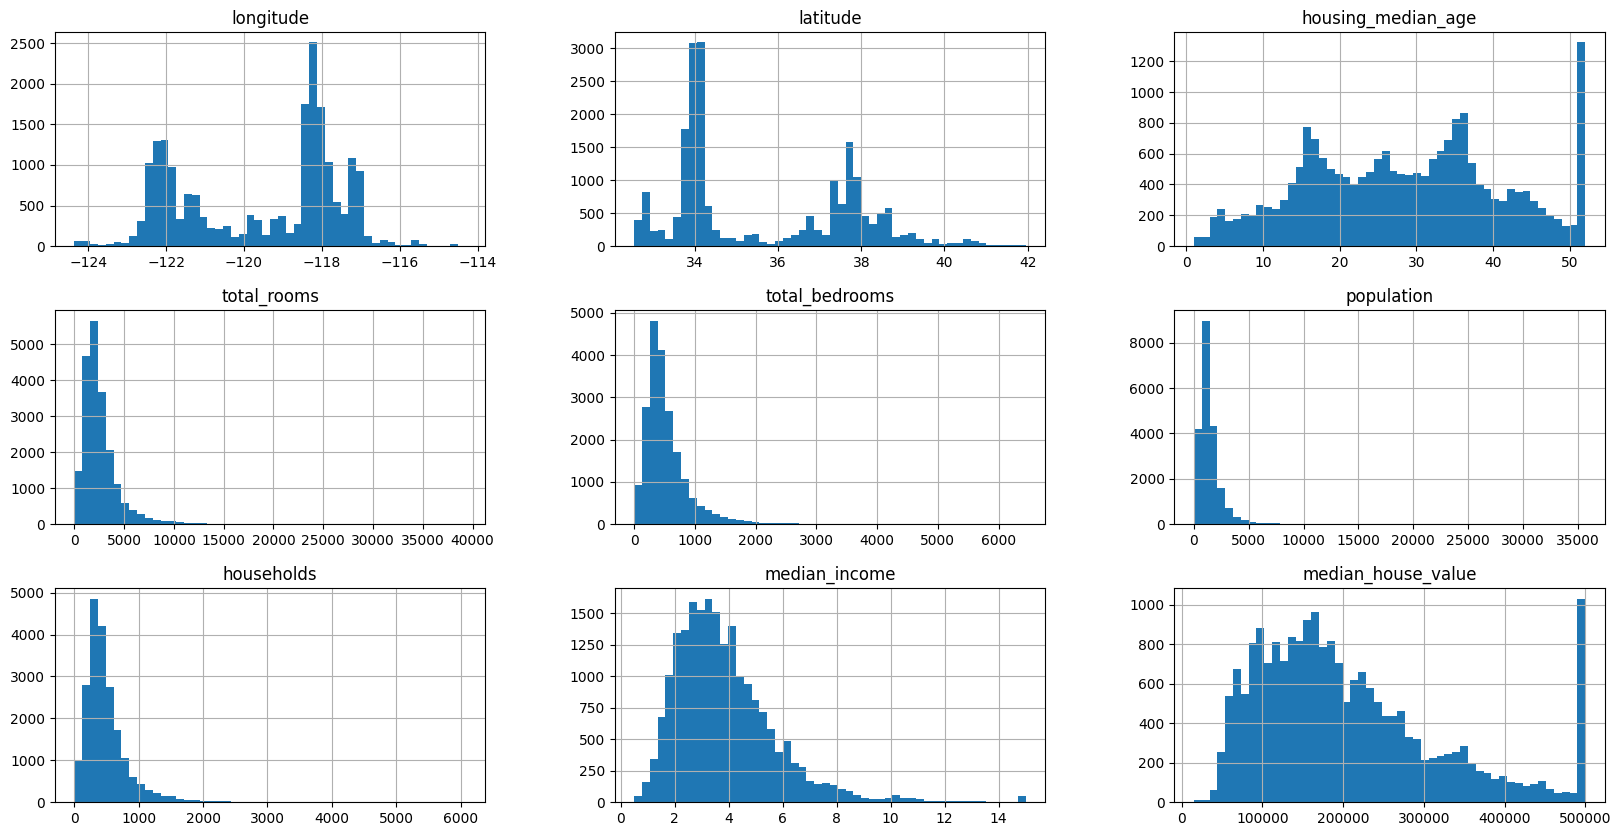

In [92]:
df.hist(bins = 50 , figsize = (20,10))
plt.show()

In [93]:
def train_test_split(df,ratio):
  shuffled_indices = np.permutation(len(df))
  test_set_size = int(ratio*len(df))
  train = df.iloc[shuffled_indices[test_set_size:]]
  test = df.iloc[shuffled_indices[:test_set_size]]
  return train,test

In [94]:
def test_of_worth(identifier,ratio,hash):
  return hash(np.int64(identifier)).digest()[-1] < 256*ratio
def train_test(data,id_column,ratio,hash = hashlib.md5):
  ids = data[id_column]
  in_test_set = ids.apply(lambda id_ : test_of_worth(id_,ratio,hash))
  return data.loc[~in_test_set],data.loc[in_test_set]

In [95]:
df.reset_index(inplace = True)

In [96]:
df['id'] = df['latitude']*1000 + df['longitude']

In [97]:
train,test = train_test(df,'id',0.2)

In [98]:
print(f"{len(train)} train and {len(test)} test")

16133 train and 4507 test


In [99]:
df["income_category"] = np.ceil(df["median_income"]/1.5)
df

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id,income_category
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,37757.77,6.0
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,37737.78,6.0
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,37727.76,5.0
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,37727.75,4.0
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,37727.75,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,39358.91,2.0
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,39368.79,2.0
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,39308.78,2.0
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,39308.68,2.0


In [100]:
df["income_category"].value_counts()

,count
income_category,
3.0,7236
2.0,6581
4.0,3639
5.0,1423
1.0,822
6.0,532
7.0,189
8.0,105
9.0,50


In [101]:
df["income_category"] = df["income_category"].where(df["income_category"] <5 , 5)
df

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id,income_category
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,37757.77,5.0
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,37737.78,5.0
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,37727.76,5.0
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,37727.75,4.0
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,37727.75,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,39358.91,2.0
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,39368.79,2.0
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,39308.78,2.0
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,39308.68,2.0


In [102]:
df["income_category"].value_counts()

,count
income_category,
3.0,7236
2.0,6581
4.0,3639
5.0,2362
1.0,822


In [103]:
ss = StratifiedShuffleSplit()

In [104]:
train1 = []
test1 = []
for train_index,test_index in ss.split(df,df['income_category']):
  train1.append(train_index)
  test1.append(test_index)

In [105]:
train_index,test_index = train1[0],test1[0]

In [106]:
strat_train_set = df.iloc[train_index]
strat_test_set = df.iloc[test_index]


In [107]:
strat_train_set.drop(["id"],axis =1, inplace = True)

<ipython-input-107-b3ad179c09f2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_train_set.drop(["id"],axis =1, inplace = True)


In [108]:
df = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

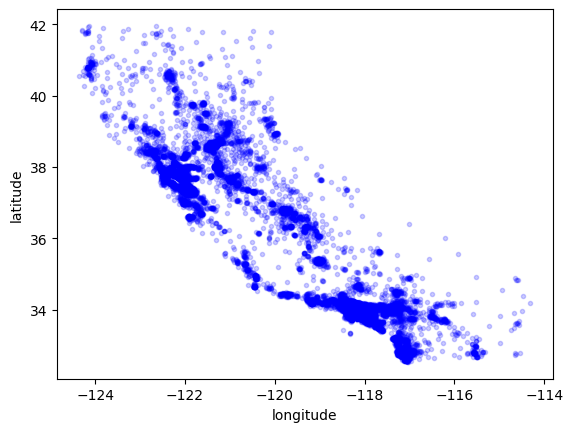

In [109]:
df.plot(kind='scatter',x = "longitude", y = "latitude",s=9,c='b',alpha = 0.2)

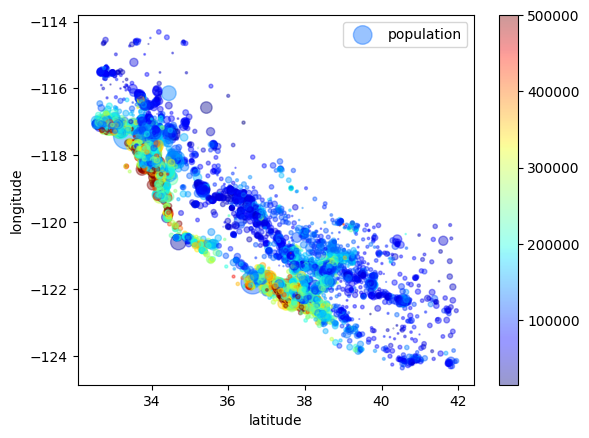

In [110]:
df.plot(kind = 'scatter',x='latitude',y='longitude',alpha=0.4,s = df['population']/100,label = 'population',c=df['median_house_value'],cmap =plt.get_cmap('jet'),colorbar=True,)
plt.legend()

In [111]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,8215
INLAND,5906
NEAR OCEAN,2386
NEAR BAY,2064
ISLAND,5


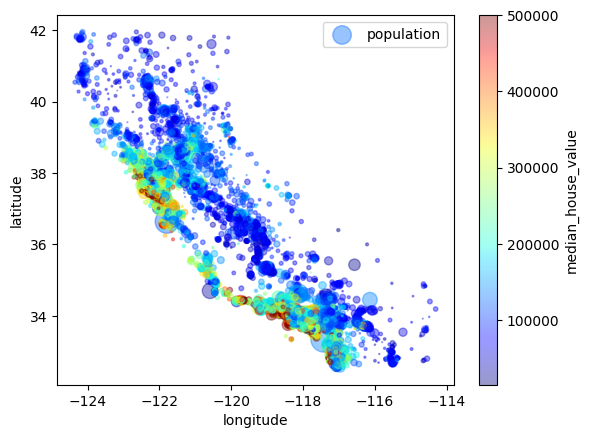

In [112]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=df["population"]/100, label="population",
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [113]:
dupe_df = df.drop('ocean_proximity',axis = 1)

In [114]:
corr = dupe_df.corr()
corr['median_house_value'].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688260
income_category,0.644121
total_rooms,0.135037
housing_median_age,0.106278
index,0.072079
households,0.066077
total_bedrooms,0.049598
population,-0.024120
longitude,-0.045564


In [115]:
df.columns

Index(['index', 'longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_category'],
      dtype='object')

<Axes: xlabel='median_house_value', ylabel='median_income'>

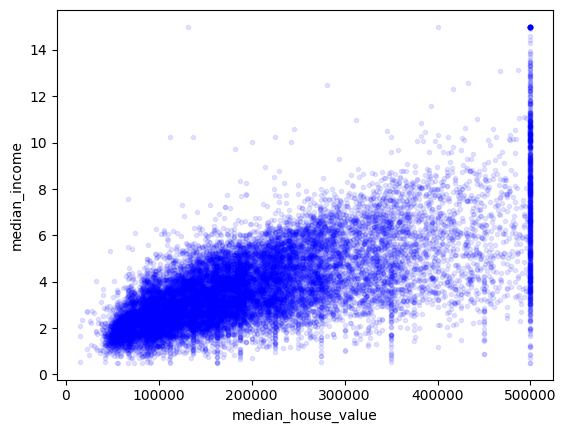

In [116]:
df.plot(kind = 'scatter' , x = 'median_house_value' , y = 'median_income' , c = 'b' , s = 9,alpha = 0.1)

In [117]:
df = strat_train_set.drop('median_house_value',axis =1)
labels = strat_train_set['median_house_value'].copy()

In [118]:
imputer = SimpleImputer(strategy = 'median')

In [119]:
num_df = df.drop('ocean_proximity',axis = 1 )

In [120]:
imputer.fit(num_df)

SimpleImputer(strategy='median')

In [121]:
X = imputer.transform(num_df)

In [122]:
train_df = pd.DataFrame(X,columns = num_df.columns)

In [123]:
from sklearn.preprocessing import OneHotEncoder,LabelBinarizer

In [124]:
encoder = LabelBinarizer(sparse_output= True)

In [125]:
enc_cat = df['ocean_proximity']
enc_cat_encoded = encoder.fit_transform(enc_cat)
enc_cat_encoded

<18576x5 sparse matrix of type '<class 'numpy.int64'>'
	with 18576 stored elements in Compressed Sparse Row format>

In [126]:
one_hot_encoded_cat = encoder.fit_transform(enc_cat)
one_hot_encoded_cat

<18576x5 sparse matrix of type '<class 'numpy.int64'>'
	with 18576 stored elements in Compressed Sparse Row format>

In [127]:
df.values

array([[10140, -117.89, 33.92, ..., 2.3935, '<1H OCEAN', 2.0],
       [19987, -119.32, 36.2, ..., 2.2262, 'INLAND', 2.0],
       [4246, -118.33, 34.12, ..., 6.0352, '<1H OCEAN', 5.0],
       ...,
       [15212, -117.09, 32.98, ..., 2.3182, '<1H OCEAN', 2.0],
       [15896, -122.39, 37.72, ..., 1.1125, 'NEAR BAY', 1.0],
       [18207, -122.05, 37.37, ..., 3.4028, '<1H OCEAN', 3.0]],
      dtype=object)

In [128]:
rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

In [184]:
class CombinedAttributeAdder(BaseEstimator,TransformerMixin):
  def __init__(self):
    self.add_bedrooms_per_person = True
  def fit(self,X,y=None):
    return self
  def transform(self,X,y=None):
    rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
    population_per_household = X[:, population_ix] / X[:, household_ix]
    bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
    return np.c_[X,rooms_per_household,population_per_household,bedrooms_per_room]
add_attr = CombinedAttributeAdder()
df_extra_attributes = add_attr.transform(df.values)

In [130]:
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.preprocessing import StandardScaler

In [131]:
num_attribs = list(num_df)
cat_attribs = ['ocean_proximity']

In [132]:
num_attribs

['index',
 'longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'income_category']

In [185]:
class DataFrameSelector(BaseEstimator,TransformerMixin):
  def __init__(self,attr_names):
    self.attr_names = attr_names
  def fit(self,X,y=None):
    return self
  def transform(self,X,y=None):
    return X[self.attr_names].values
  def fit_transform(self,X,y = None):
    return X[self.attr_names].values

In [141]:
from sklearn.compose import ColumnTransformer

In [195]:
num_pipeline = Pipeline([
        ('selector',DataFrameSelector(num_attribs)),
        ('attr_adder',CombinedAttributeAdder()),
        ('Imputer', SimpleImputer(strategy = 'median')),
        ('Std_scaler',StandardScaler()),
    ])
cat_pipeline = Pipeline([
        ('selector', DataFrameSelector(cat_attribs)),
        ('one_hot_encoder', OneHotEncoder(handle_unknown="ignore")),
    ])
full_pipeline = FeatureUnion(transformer_list =  [('num_pipeline',num_pipeline),
                        ('cat_pipeline',cat_pipeline),
                         ])

In [196]:
df_tr = full_pipeline.fit_transform(df)

In [178]:
df_tr.shape

(18576, 18)

In [180]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(df_tr,labels)

LinearRegression()

In [232]:
some_data = df.iloc[:10]
some_data_prepared = full_pipeline.transform(some_data)
real_values = labels[:10].values
for i in range(len(some_data)):
  a = real_values[i]
  b = lin_reg.predict(some_data_prepared)[i]
  print(f"{a} : {b}")

125000.0 : 159842.35596151737
64500.0 : 81185.26892571789
500001.0 : 325300.17519923707
206300.0 : 180495.67608673556
128100.0 : 178377.5663052768
209800.0 : 272394.28283863
224100.0 : 254728.04408254888
200000.0 : 141371.29403157334
135200.0 : 185956.50606983947
286100.0 : 246611.8590844908


In [229]:
from sklearn.metrics import mean_squared_error
df_predictions = lin_reg.predict(df_tr)
lin_mse = mean_squared_error(labels, df_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

67652.54251859787

In [235]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(df_tr,labels)
for i in range(len(some_data)):
  a = real_values[i]
  b = tree_reg.predict(some_data_prepared)[i]
  print(f"{a} : {b}")

125000.0 : 125000.0
64500.0 : 64500.0
500001.0 : 500001.0
206300.0 : 206300.0
128100.0 : 128100.0
209800.0 : 209800.0
224100.0 : 224100.0
200000.0 : 200000.0
135200.0 : 135200.0
286100.0 : 286100.0


In [237]:
df_predictions = tree_reg.predict(df_tr)
tree_mse = mean_squared_error(labels, df_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

In [238]:
from sklearn.model_selection import cross_val_score

In [259]:
tree_scores = cross_val_score(tree_reg,df_tr,labels,scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)
tree_rmse_scores

array([65093.32666861, 69599.43210887, 69838.14500065, 72999.3903173 ,
       71965.95388191, 70243.10249145, 70887.79362504, 67821.09683741,
       73645.64768674, 68620.37063246])

In [255]:
def display_scores(scores):
  print(f"Scores : {scores}")
  print(f"Mean : {scores.mean()}")
  print(f"Standard_deviation : {scores.std()}")

In [262]:
display_scores(tree_rmse_scores)

Scores : [65093.32666861 69599.43210887 69838.14500065 72999.3903173
 71965.95388191 70243.10249145 70887.79362504 67821.09683741
 73645.64768674 68620.37063246]
Mean : 70071.42592504463
Standard_deviation : 2405.439975396154


In [260]:
lin_scores = cross_val_score(tree_reg,df_tr,labels,scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
lin_rmse_scores

array([65412.25808344, 71509.81630686, 70611.07943753, 73106.52346127,
       70550.00191975, 71466.05272339, 71016.09547884, 67245.37144962,
       71619.98958662, 67041.89205965])

In [261]:
display_scores(lin_rmse_scores)

Scores : [65412.25808344 71509.81630686 70611.07943753 73106.52346127
 70550.00191975 71466.05272339 71016.09547884 67245.37144962
 71619.98958662 67041.89205965]
Mean : 69957.90805069679
Standard_deviation : 2361.781530235384


In [263]:
from sklearn.ensemble import RandomForestRegressor

In [266]:
rand_reg = RandomForestRegressor()
rand_reg.fit(df_tr,labels)
rand_scores = cross_val_score(rand_reg,df_tr,labels,scoring="neg_mean_squared_error",cv = 10)
rand_rmse_scores = np.sqrt(-rand_scores)
display_scores(rand_rmse_scores)

Scores : [-2.26686345e+09 -2.28987577e+09 -2.32573223e+09 -2.71705663e+09
 -2.52699728e+09 -2.18020886e+09 -2.58460815e+09 -2.39092552e+09
 -2.57806319e+09 -2.40879883e+09]
Mean : -2426912989.7134223
Standard_deviation : 160945049.16715863


In [267]:
rand_rmse_scores = np.sqrt(-rand_scores)
display_scores(rand_rmse_scores)

Scores : [47611.58947429 47852.64643829 48225.84603757 52125.39330672
 50269.24783999 46692.70672616 50839.04156145 48897.09111991
 50774.63133329 49079.5153458 ]
Mean : 49236.77091834597
Standard_deviation : 1628.9196566264416


In [269]:
df_predictions = rand_reg.predict(df_tr)

In [271]:
rand_mse = mean_squared_error(labels, df_predictions)
rand_rmse = np.sqrt(rand_mse)
rand_rmse

18251.927964263145

In [ ]:
from sklearn.model_selection import GridSearchCV
